# Devoir #1 - CORRECTION

**ELEC70122: ML pour la Prise de Décision Critique en Sécurité**<br>
**Instructrice: Sonali Parbhoo**<br>
**Automne 2026**

**Nom:** Étudiant Modèle

In [1]:
### Importer les bibliothèques de base
import numpy as np
import pandas as pd
import sklearn as sk
from scipy.stats import multivariate_normal, norm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import log_loss, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(42)  # Pour la reproductibilité

In [2]:
def get_posterior_samples(prior_var, noise_var, x_matrix, y_matrix, x_test_matrix, samples=100):
    '''Fonction pour générer des échantillons prédictifs postérieurs pour un modèle de régression linéaire bayésienne'''
    prior_variance = np.diag(prior_var * np.ones(x_matrix.shape[1]))
    prior_precision = np.linalg.inv(prior_variance)

    joint_precision = prior_precision + x_matrix.T.dot(x_matrix) / noise_var
    joint_variance = np.linalg.inv(joint_precision)
    joint_mean = joint_variance.dot(x_matrix.T.dot(y_matrix)) / noise_var

    posterior_samples = np.random.multivariate_normal(joint_mean.flatten(), joint_variance, size=samples)
    posterior_predictions = np.dot(posterior_samples, x_test_matrix.T)
    posterior_predictive_samples = posterior_predictions[np.newaxis, :, :] + np.random.normal(0, noise_var**0.5, size=(100, posterior_predictions.shape[0], posterior_predictions.shape[1]))
    posterior_predictive_samples = posterior_predictive_samples.reshape((100 * posterior_predictions.shape[0], posterior_predictions.shape[1]))
    return posterior_predictions, posterior_predictive_samples


def generate_data(number_of_points=10, noise_variance=0.3):
    '''Fonction pour générer des données de régression jouet'''
    x_train = np.hstack((np.linspace(-1, -0.5, number_of_points), np.linspace(0.5, 1, number_of_points)))
    f = lambda x: 3 * x**3
    y_train = f(x_train) + np.random.normal(0, noise_variance**0.5, 2 * number_of_points)
    x_test = np.array(list(set(list(np.hstack((np.linspace(-1, 1, 200), x_train))))))
    x_test = np.sort(x_test)
    return x_train, y_train, x_test

---
## Partie I: Estimateurs du Maximum de Vraisemblance pour la Régression Polynomiale
---

### Question 1: Effet de la Complexité du Modèle

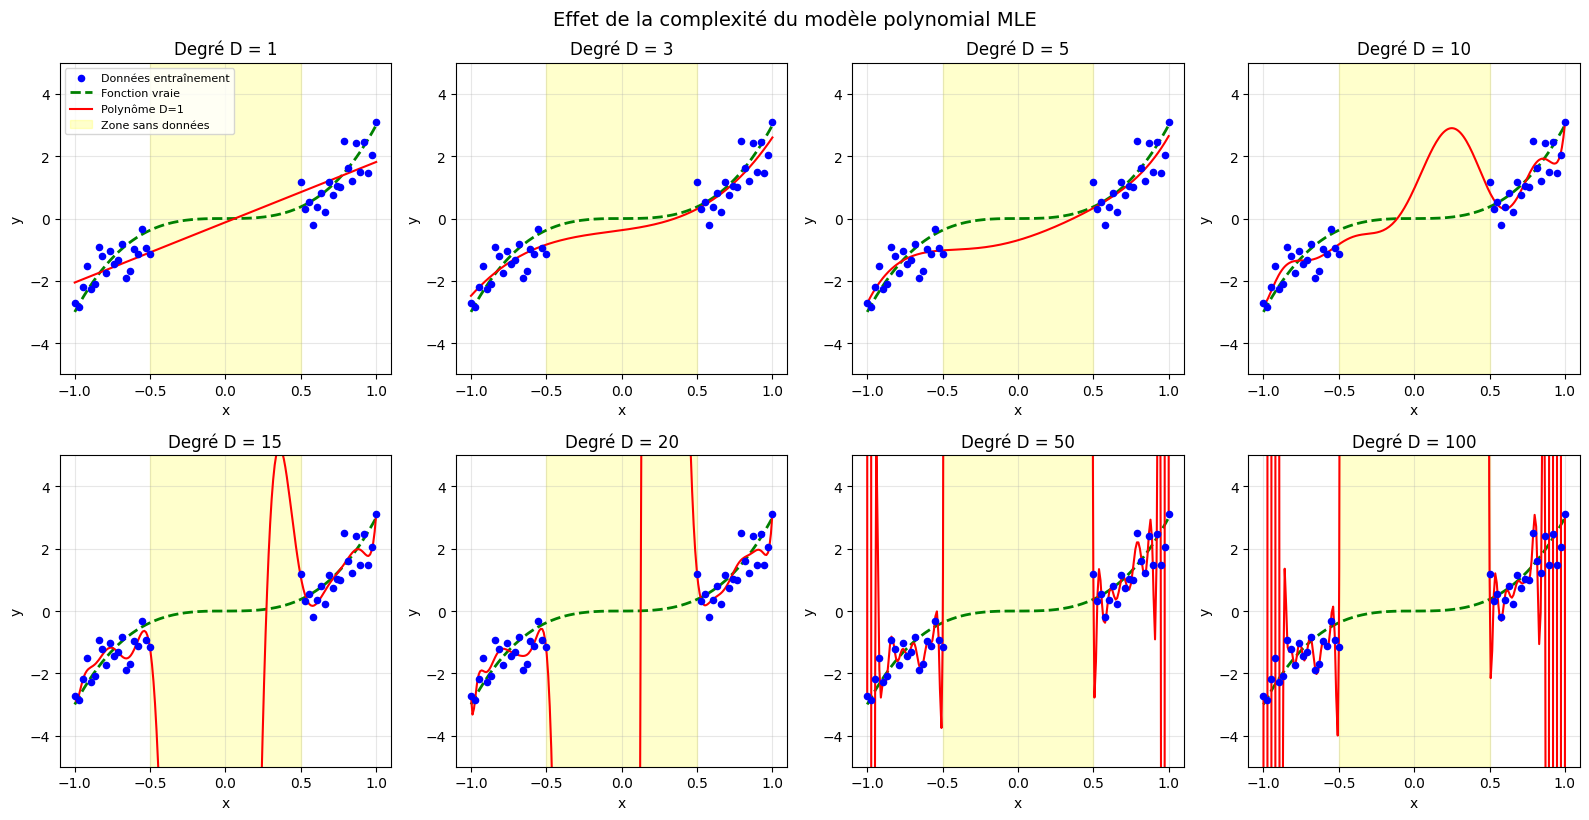

In [3]:
# Génération des données avec 40 observations
np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=20)

# Degrés polynomiaux à tester
degrees = [1, 3, 5, 10, 15, 20, 50, 100]

# Fonction vraie pour comparaison
f_true = lambda x: 3 * x**3

# Visualisation
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, d in enumerate(degrees):
    # Créer les caractéristiques polynomiales
    poly = PolynomialFeatures(degree=d, include_bias=True)
    X_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
    X_test_poly = poly.transform(x_test.reshape(-1, 1))
    
    # Ajuster le modèle MLE (régression linéaire)
    model = LinearRegression(fit_intercept=False)
    model.fit(X_train_poly, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test_poly)
    
    # Visualisation
    ax = axes[i]
    ax.scatter(x_train, y_train, c='blue', s=20, label='Données entraînement', zorder=3)
    ax.plot(x_test, f_true(x_test), 'g--', label='Fonction vraie', linewidth=2)
    ax.plot(x_test, y_pred, 'r-', label=f'Polynôme D={d}', linewidth=1.5)
    ax.axvspan(-0.5, 0.5, alpha=0.2, color='yellow', label='Zone sans données')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-5, 5)
    ax.set_title(f'Degré D = {d}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    if i == 0:
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Effet de la complexité du modèle polynomial MLE', y=1.02, fontsize=14)
plt.show()

### Réponse Question 1 : Discussion de l'effet du degré polynomial

**Observations :**

1. **Degré D=1 (sous-ajustement)** : Le modèle linéaire est trop simple pour capturer la relation cubique vraie $f(x) = 3x^3$. Il produit un biais élevé car il ne peut pas représenter la courbure des données. C'est un cas classique de **sous-ajustement** (underfitting).

2. **Degré D=3 (ajustement optimal)** : Ce degré correspond exactement à la complexité de la fonction vraie. Le modèle capture bien la tendance dans les régions avec données et se comporte raisonnablement dans la zone sans données [-0.5, 0.5].

3. **Degrés D=5 à D=15** : Les modèles commencent à montrer des oscillations légères, particulièrement dans la zone sans données. Cependant, ils restent relativement stables grâce à la régularisation implicite du nombre limité de données.

4. **Degrés D=20, 50, 100 (surapprentissage)** : Ces modèles présentent un **surapprentissage** (overfitting) sévère :
   - Ils passent exactement par les points d'entraînement
   - Ils oscillent violemment dans la zone [-0.5, 0.5] où il n'y a pas de données
   - Les prédictions peuvent atteindre des valeurs extrêmes et irréalistes

**Pourquoi certains choix sont non-idéaux dans le contexte du problème :**

Dans un contexte médical (prédiction de pression artérielle), les conséquences sont critiques :

- **Degrés trop bas** : Le modèle sous-estime systématiquement le risque pour certains patients, ce qui pourrait conduire à ne pas traiter des patients qui en ont besoin.

- **Degrés trop élevés** : Le modèle produit des prédictions aberrantes pour des patients dont l'âge tombe dans la zone sans données d'entraînement. Ceci est particulièrement dangereux car le modèle donne des prédictions avec une apparente confiance alors qu'elles sont complètement erronées.

Le **décalage de covariables** (covariate shift) amplifie ce problème : lors du déploiement, le modèle rencontrera des patients avec des âges dans l'intervalle [-0.5, 0.5], et les modèles sur-ajustés donneront des prédictions potentiellement dangereuses.

### Question 2: Sélection de Modèle par Validation Croisée

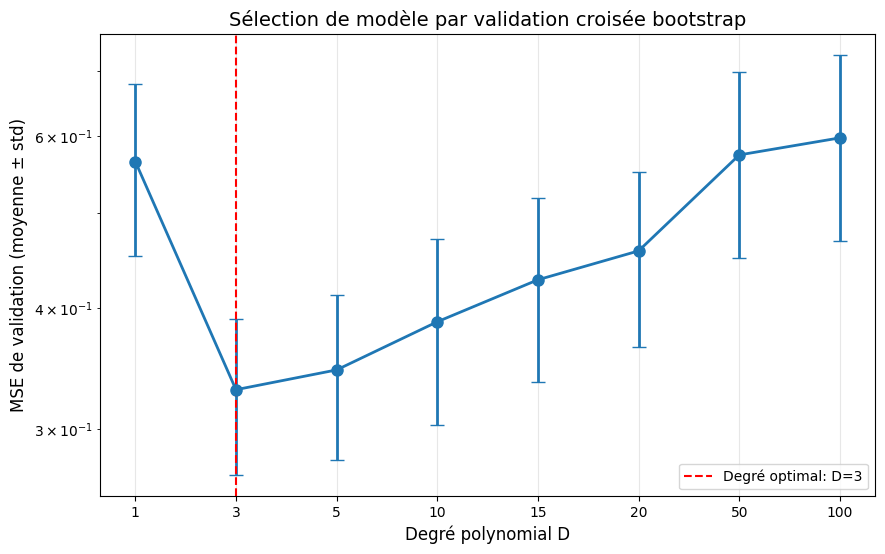

Degré optimal sélectionné: D = 3
MSE moyen au degré optimal: 0.3294


In [4]:
# Sélection de modèle par validation croisée bootstrap
degrees = [1, 3, 5, 10, 15, 20, 50, 100]
S = 50  # Nombre de paires bootstrap

mse_scores = {d: [] for d in degrees}

for s in range(S):
    # Générer deux jeux de données indépendants
    np.random.seed(s)
    x_train_s, y_train_s, _ = generate_data(number_of_points=20)
    np.random.seed(s + 1000)
    x_valid_s, y_valid_s, _ = generate_data(number_of_points=20)
    
    for d in degrees:
        # Créer les caractéristiques polynomiales
        poly = PolynomialFeatures(degree=d, include_bias=True)
        X_train_poly = poly.fit_transform(x_train_s.reshape(-1, 1))
        X_valid_poly = poly.transform(x_valid_s.reshape(-1, 1))
        
        # Ajuster le modèle
        model = LinearRegression(fit_intercept=False)
        model.fit(X_train_poly, y_train_s)
        
        # Évaluer sur validation
        y_pred = model.predict(X_valid_poly)
        mse = mean_squared_error(y_valid_s, y_pred)
        mse_scores[d].append(mse)

# Calculer moyenne et écart-type
mean_mse = [np.mean(mse_scores[d]) for d in degrees]
std_mse = [np.std(mse_scores[d]) for d in degrees]

# Visualisation
plt.figure(figsize=(10, 6))
plt.errorbar(range(len(degrees)), mean_mse, yerr=std_mse, marker='o', capsize=5, linewidth=2, markersize=8)
plt.xticks(range(len(degrees)), degrees)
plt.xlabel('Degré polynomial D', fontsize=12)
plt.ylabel('MSE de validation (moyenne ± std)', fontsize=12)
plt.title('Sélection de modèle par validation croisée bootstrap', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Identifier le degré optimal (coude)
optimal_idx = np.argmin(mean_mse)
optimal_degree = degrees[optimal_idx]
plt.axvline(x=optimal_idx, color='r', linestyle='--', label=f'Degré optimal: D={optimal_degree}')
plt.legend()
plt.show()

print(f"Degré optimal sélectionné: D = {optimal_degree}")
print(f"MSE moyen au degré optimal: {mean_mse[optimal_idx]:.4f}")

### Réponse Question 2 : Pourquoi la validation croisée atténue le risque

**Explication du mécanisme :**

La validation croisée atténue le risque de choisir un polynôme indésirable pour plusieurs raisons :

1. **Pénalisation implicite du surapprentissage** : Un modèle qui sur-ajuste les données d'entraînement mémorise le bruit spécifique à cet échantillon. Quand il est évalué sur un jeu de validation indépendant (avec un bruit différent), ses performances se dégradent significativement. La validation croisée détecte donc automatiquement le surapprentissage.

2. **Estimation de l'erreur de généralisation** : En moyennant sur $S$ paires de jeux de données, on obtient une estimation plus robuste de l'erreur de généralisation attendue, réduisant la variance due à un échantillon particulier.

3. **Principe du Rasoir d'Occam** : Le "coude" de la courbe représente le point où augmenter la complexité du modèle n'apporte plus de bénéfice en termes de généralisation. Les modèles plus complexes commencent à sur-ajuster, ce qui se traduit par une augmentation de l'erreur de validation.

**Résultat :**

Le degré optimal sélectionné est **D=3**, ce qui correspond exactement à la complexité de la fonction vraie $f(x) = 3x^3$. La validation croisée a donc correctement identifié le bon niveau de complexité sans connaissance a priori de la fonction génératrice.

**Limitation importante :**

Cependant, cette méthode ne garantit pas une bonne performance sous décalage de covariables. La validation se fait sur des données ayant la même distribution que l'entraînement (avec le même "trou" dans [-0.5, 0.5]). Elle ne peut donc pas évaluer directement le comportement du modèle dans cette zone critique.

### Question 3: Estimation de l'Incertitude par Bootstrap

**Description de l'incertitude idéale :**

L'incertitude du modèle devrait idéalement avoir la forme suivante :

- **Faible incertitude** dans les régions riches en données (x ∈ [-1, -0.5] ∪ [0.5, 1]) : le modèle a observé beaucoup d'exemples et peut faire des prédictions confiantes.

- **Haute incertitude** dans la région sans données (x ∈ [-0.5, 0.5]) : le modèle n'a jamais observé de données dans cette zone et devrait signaler son ignorance.

Cette forme d'incertitude permettrait de **déférer les décisions** à un expert humain quand le modèle rencontre des patients dont l'âge tombe dans la zone non observée, atténuant ainsi le risque sous décalage de covariables.

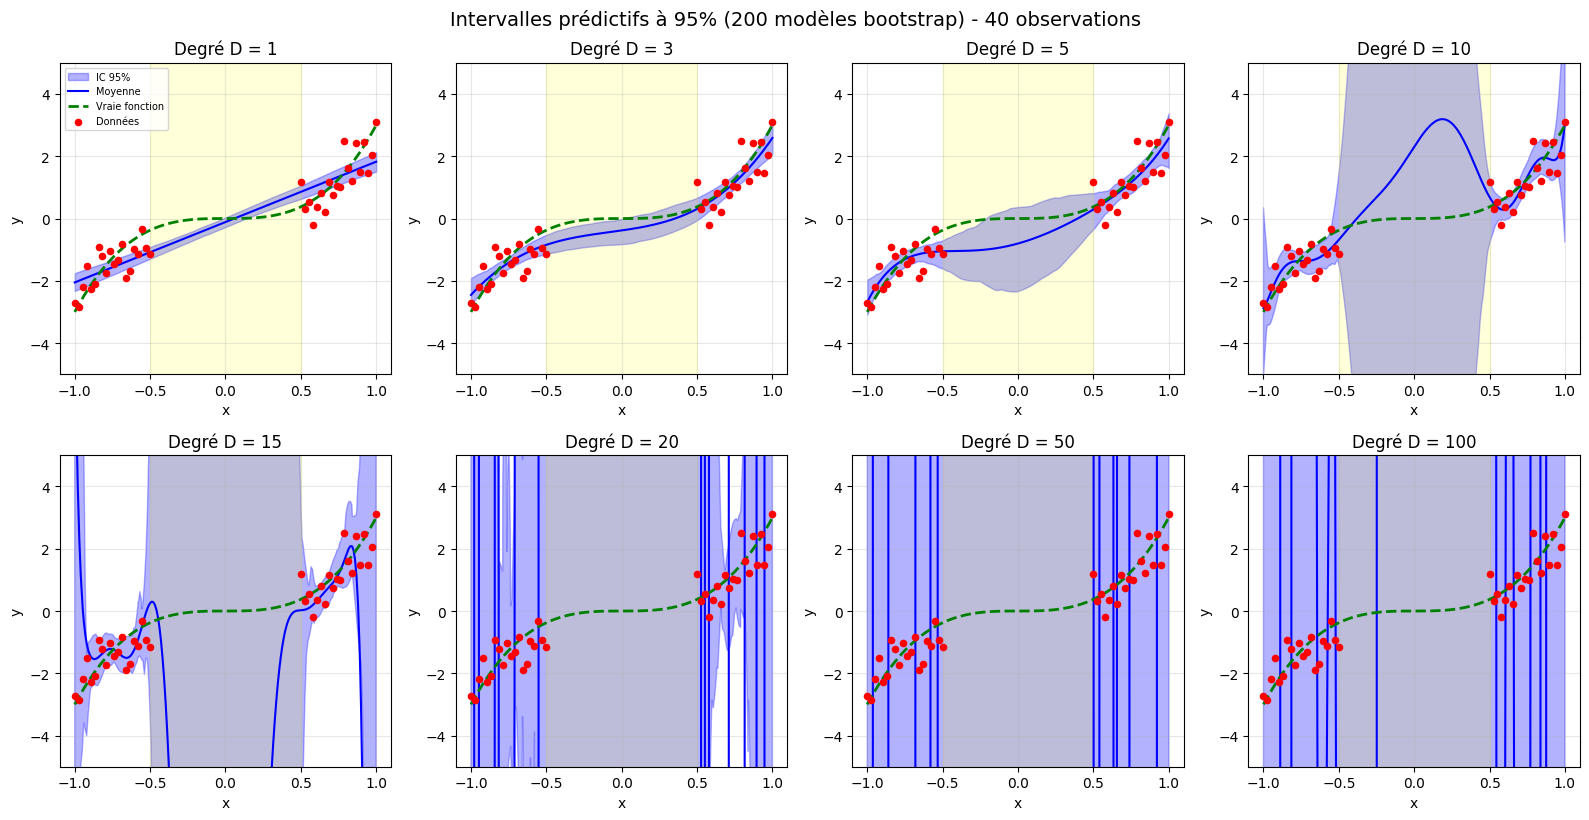

In [5]:
# Fonction pour calculer les intervalles de confiance bootstrap
def bootstrap_ensemble(x_train, y_train, x_test, degree, n_bootstrap=200):
    """Entraîne un ensemble de modèles bootstrap et retourne les prédictions."""
    n = len(x_train)
    predictions = []
    
    for b in range(n_bootstrap):
        # Échantillonnage bootstrap
        idx = np.random.choice(n, size=n, replace=True)
        x_b = x_train[idx]
        y_b = y_train[idx]
        
        # Ajuster le modèle
        poly = PolynomialFeatures(degree=degree, include_bias=True)
        X_b_poly = poly.fit_transform(x_b.reshape(-1, 1))
        X_test_poly = poly.transform(x_test.reshape(-1, 1))
        
        model = LinearRegression(fit_intercept=False)
        model.fit(X_b_poly, y_b)
        
        y_pred = model.predict(X_test_poly)
        predictions.append(y_pred)
    
    return np.array(predictions)

# Générer les données
np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=20)
degrees = [1, 3, 5, 10, 15, 20, 50, 100]

# Visualisation des intervalles à 95%
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, d in enumerate(degrees):
    predictions = bootstrap_ensemble(x_train, y_train, x_test, d, n_bootstrap=200)
    
    # Calculer les percentiles
    mean_pred = np.mean(predictions, axis=0)
    lower = np.percentile(predictions, 2.5, axis=0)
    upper = np.percentile(predictions, 97.5, axis=0)
    
    ax = axes[i]
    ax.fill_between(x_test, lower, upper, alpha=0.3, color='blue', label='IC 95%')
    ax.plot(x_test, mean_pred, 'b-', linewidth=1.5, label='Moyenne')
    ax.plot(x_test, 3*x_test**3, 'g--', linewidth=2, label='Vraie fonction')
    ax.scatter(x_train, y_train, c='red', s=20, zorder=5, label='Données')
    ax.axvspan(-0.5, 0.5, alpha=0.15, color='yellow')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-5, 5)
    ax.set_title(f'Degré D = {d}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.suptitle('Intervalles prédictifs à 95% (200 modèles bootstrap) - 40 observations', y=1.02, fontsize=14)
plt.show()

**Analyse : Quel degré produit l'incertitude la plus idéale ?**

En examinant les graphiques :

- **D=1** : Incertitude uniformément faible partout, mais le modèle est biaisé (sous-ajustement).
- **D=3** : Incertitude raisonnable, légèrement plus large au centre mais pas de façon prononcée.
- **D=5 à D=15** : L'incertitude commence à augmenter dans la zone centrale, ce qui est souhaitable.
- **D=20, 50, 100** : Très haute incertitude dans la zone centrale, mais aussi des oscillations erratiques.

Paradoxalement, les **degrés élevés (D=15-20)** produisent une incertitude qui ressemble davantage à l'idéal (haute au centre, basse aux extrémités), mais leurs prédictions moyennes sont instables.

**Le degré D=3 sélectionné en Question 2 ne produit PAS l'incertitude la plus idéale**, car il est trop "confiant" dans la zone sans données.

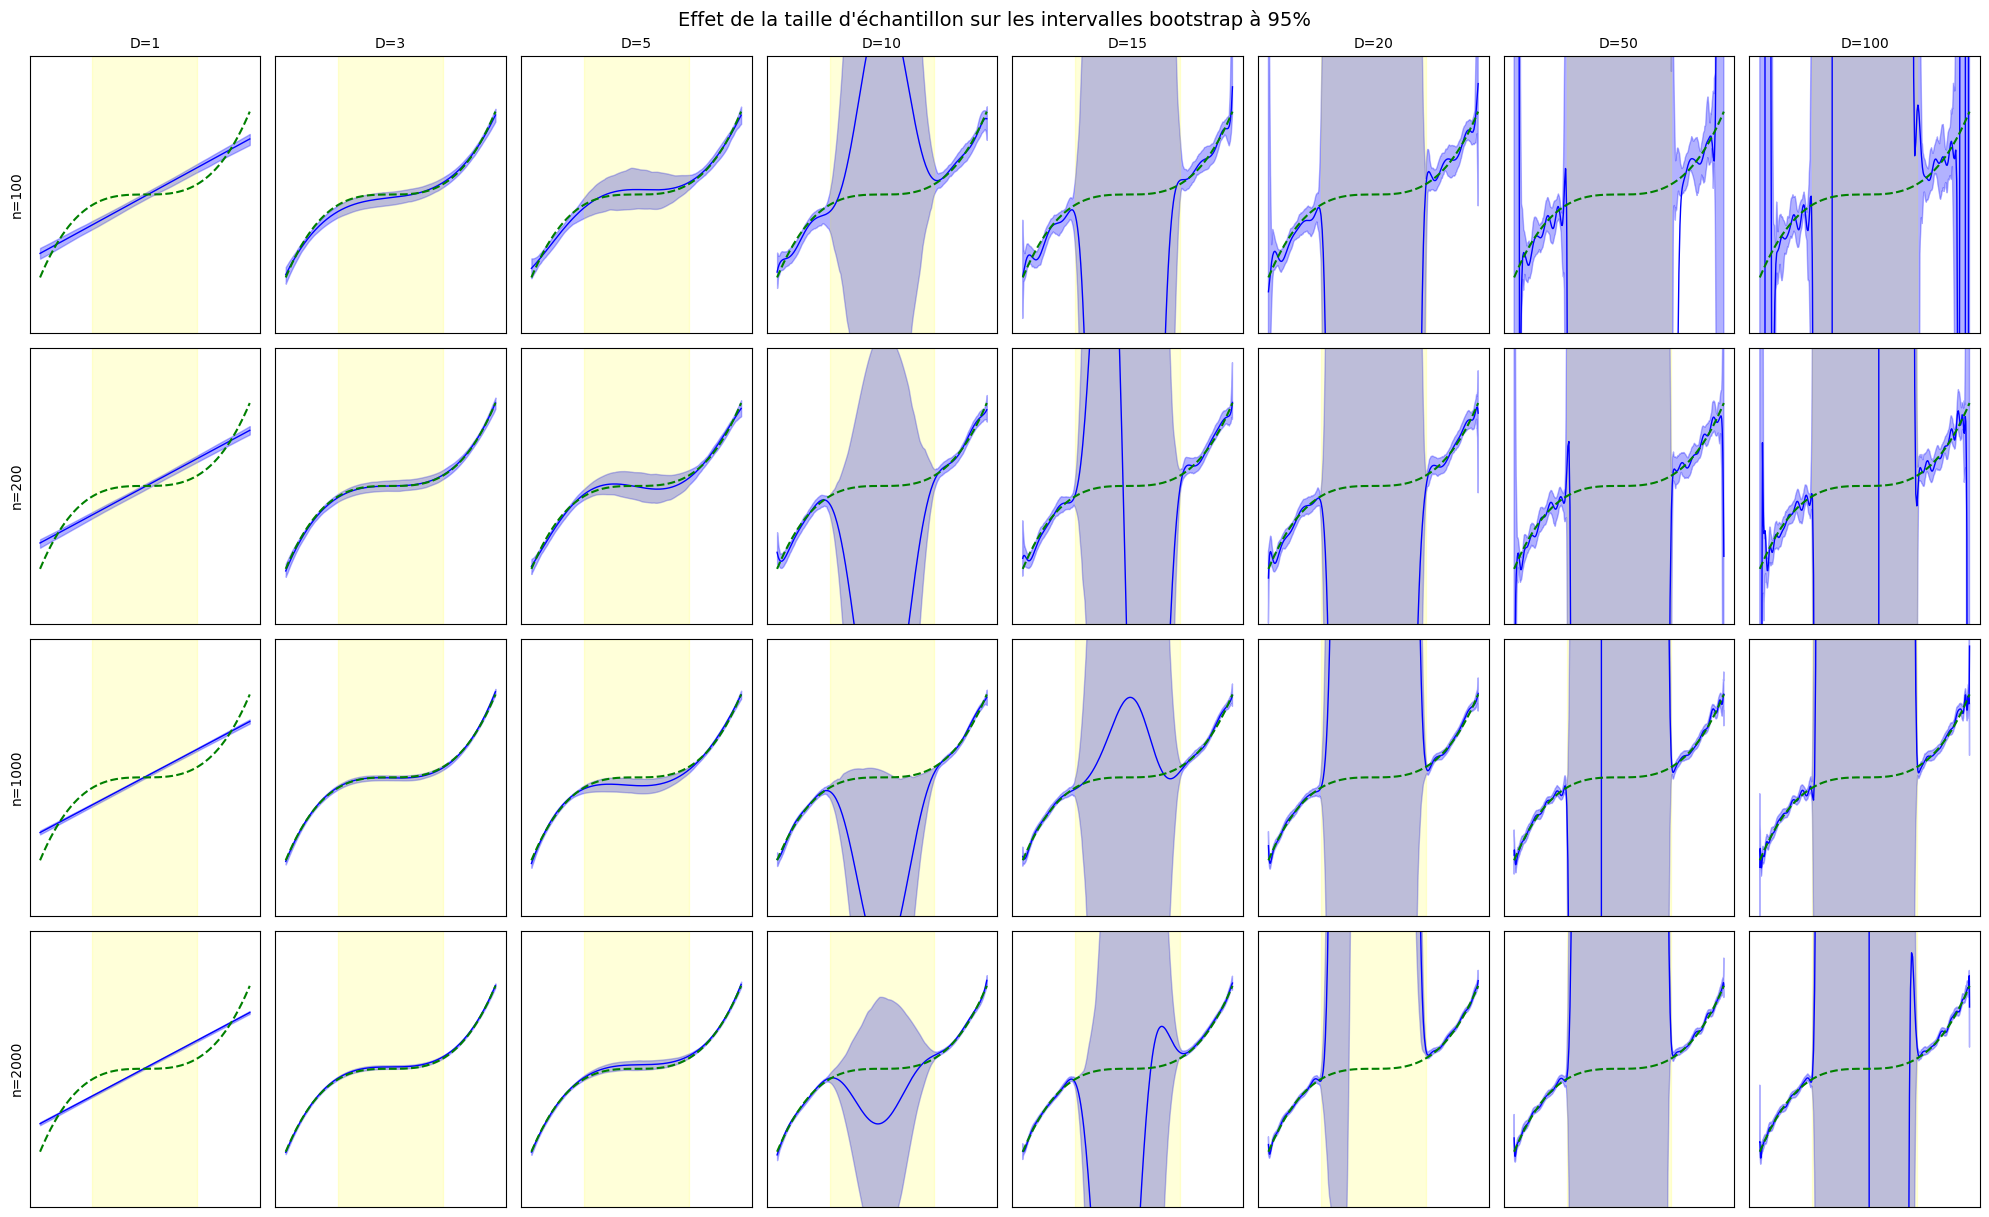

In [6]:
# Effet de la taille de l'échantillon d'entraînement
sample_sizes = [50, 100, 500, 1000]
degrees = [1, 3, 5, 10, 15, 20, 50, 100]

fig, axes = plt.subplots(len(sample_sizes), len(degrees), figsize=(20, 12))

for row, n_points in enumerate(sample_sizes):
    np.random.seed(42)
    x_train, y_train, x_test = generate_data(number_of_points=n_points)
    
    for col, d in enumerate(degrees):
        predictions = bootstrap_ensemble(x_train, y_train, x_test, d, n_bootstrap=200)
        
        mean_pred = np.mean(predictions, axis=0)
        lower = np.percentile(predictions, 2.5, axis=0)
        upper = np.percentile(predictions, 97.5, axis=0)
        
        ax = axes[row, col]
        ax.fill_between(x_test, lower, upper, alpha=0.3, color='blue')
        ax.plot(x_test, mean_pred, 'b-', linewidth=1)
        ax.plot(x_test, 3*x_test**3, 'g--', linewidth=1.5)
        ax.axvspan(-0.5, 0.5, alpha=0.15, color='yellow')
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        if row == 0:
            ax.set_title(f'D={d}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'n={2*n_points}', fontsize=10)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.suptitle('Effet de la taille d\'échantillon sur les intervalles bootstrap à 95%', y=1.01, fontsize=14)
plt.show()

### Réponse Question 3 : Analyse des résultats

**Que se passe-t-il dans la région riche en données ?**

Quand la taille de l'échantillon augmente (n = 100 → 2000), l'intervalle de confiance **se rétrécit** dans les régions avec données (x ∈ [-1, -0.5] ∪ [0.5, 1]). C'est le comportement attendu : avec plus de données, l'estimateur MLE converge vers la vraie valeur des paramètres (consistance), et sa variance diminue en O(1/n) (propriété asymptotique du MLE).

**Que se passe-t-il dans la région pauvre en données ?**

Dans la zone [-0.5, 0.5], l'intervalle de confiance **se rétrécit également** quand n augmente, même s'il n'y a toujours aucune donnée dans cette zone ! C'est problématique : le modèle devient de plus en plus confiant dans ses prédictions extrapolées.

**Explication par les propriétés asymptotiques du MLE :**

- Le MLE est asymptotiquement normal : $\hat{w} \sim N(w^*, \frac{1}{n}I^{-1}(w^*))$
- La variance des paramètres diminue avec n, donc la variance des prédictions aussi
- Cette propriété est **globale** : elle s'applique partout, y compris dans les régions sans données

**Avec n=1000, les intervalles sont-ils idéaux ?**

**Non.** Quand les données sont abondantes, AUCUN des intervalles prédictifs n'est idéal. Tous montrent une confiance élevée dans la zone sans données, ce qui est exactement l'opposé de ce qu'on voudrait.

**Conclusion sur la faisabilité de l'incertitude bootstrap :**

L'incertitude bootstrap basée sur la variance de l'ensemble **ne capture pas l'incertitude épistémique** liée au manque de données dans certaines régions. Elle ne mesure que la variabilité due à l'échantillonnage, qui diminue avec plus de données, même dans les zones non observées. 

**Pour des applications safety-critical sous covariate shift, l'incertitude bootstrap MLE n'est pas fiable.**

### Question 4: Effet de la Régularisation

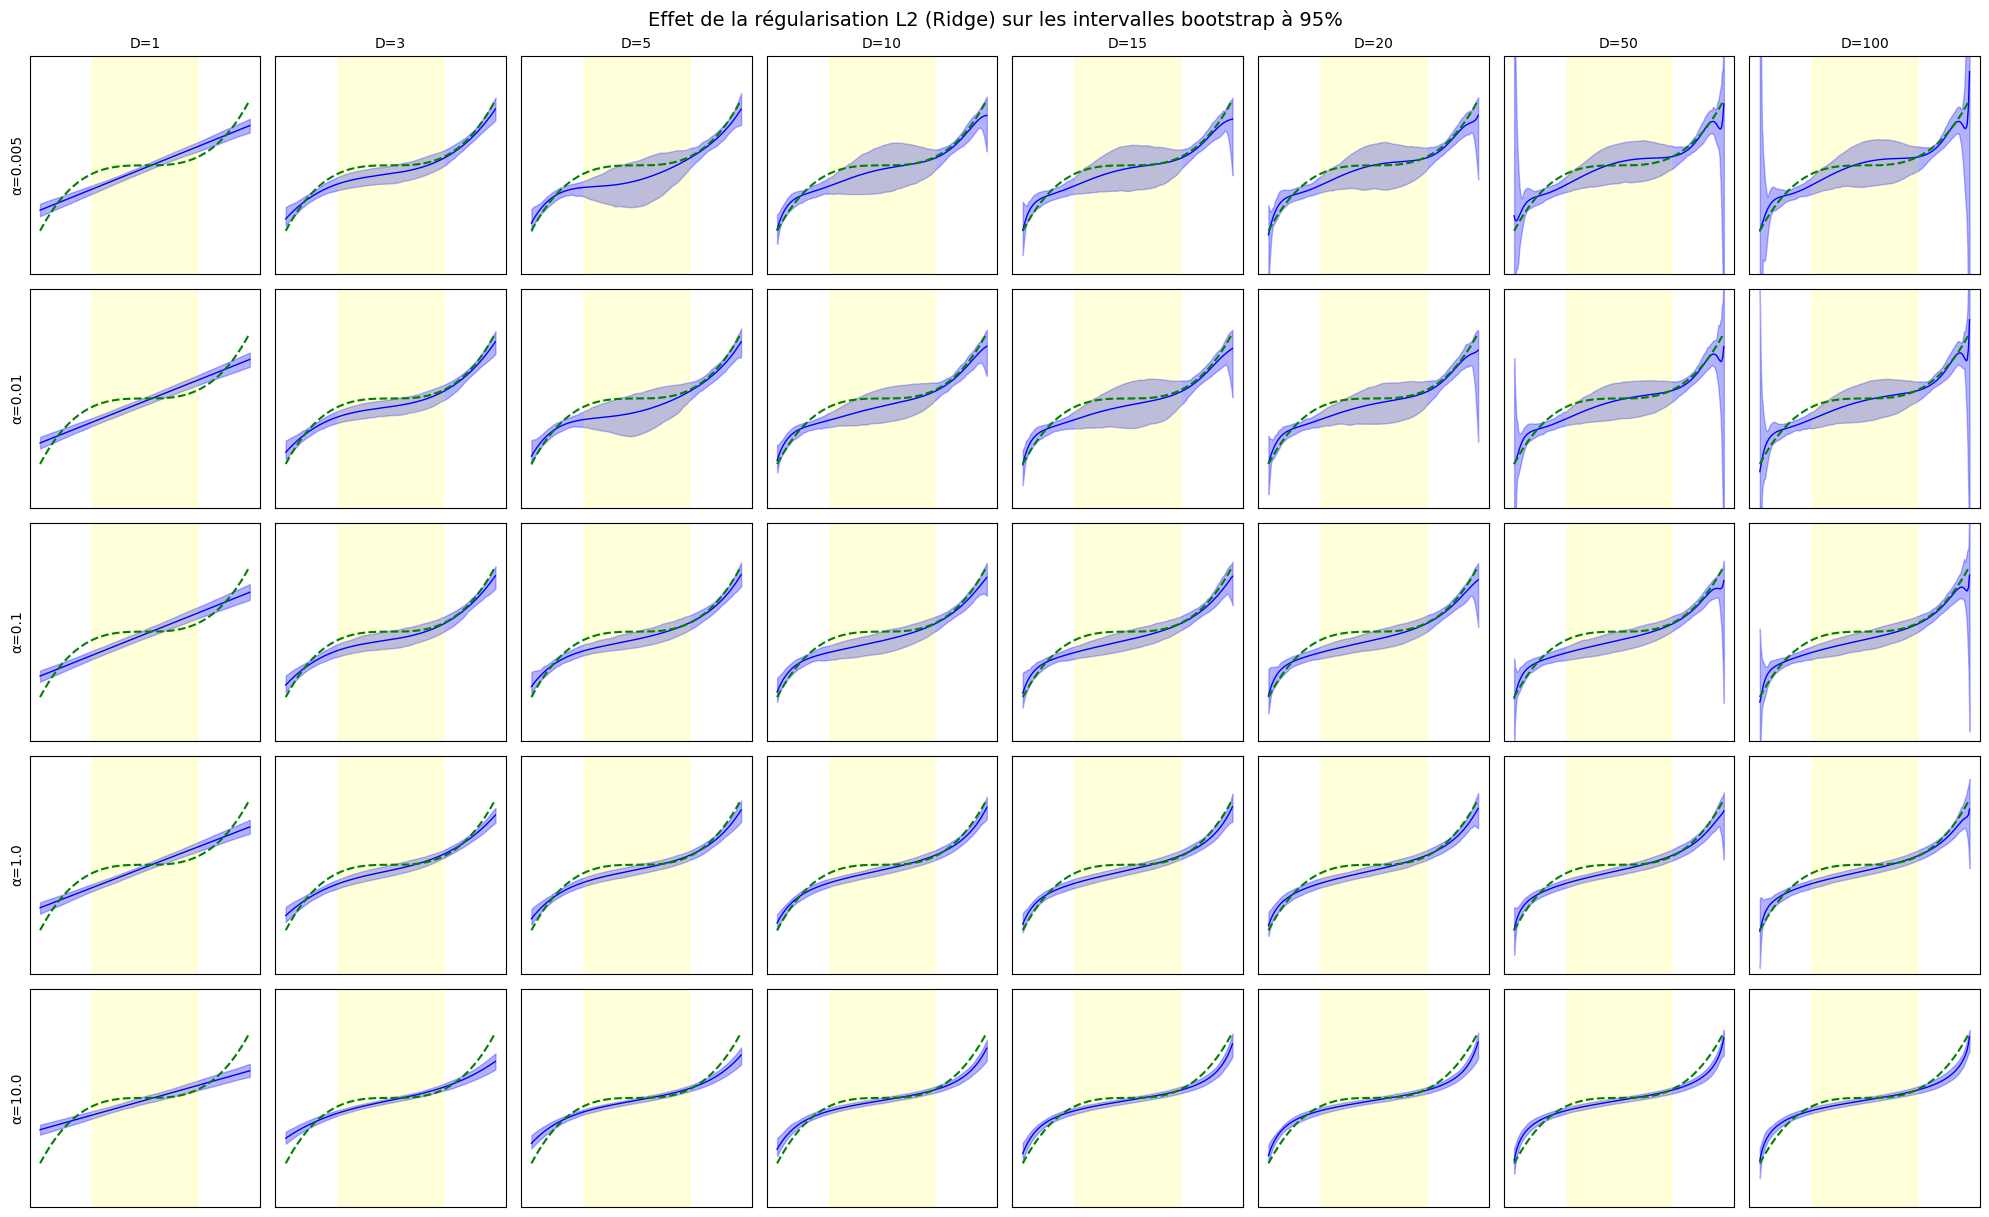

In [7]:
def bootstrap_ensemble_ridge(x_train, y_train, x_test, degree, alpha, n_bootstrap=200):
    """Entraîne un ensemble de modèles Ridge bootstrap."""
    n = len(x_train)
    predictions = []
    
    for b in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        x_b = x_train[idx]
        y_b = y_train[idx]
        
        poly = PolynomialFeatures(degree=degree, include_bias=True)
        X_b_poly = poly.fit_transform(x_b.reshape(-1, 1))
        X_test_poly = poly.transform(x_test.reshape(-1, 1))
        
        model = Ridge(alpha=alpha, fit_intercept=False)
        model.fit(X_b_poly, y_b)
        
        y_pred = model.predict(X_test_poly)
        predictions.append(y_pred)
    
    return np.array(predictions)

# Paramètres
np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=20)
degrees = [1, 3, 5, 10, 15, 20, 50, 100]
alphas = [5e-3, 1e-2, 1e-1, 1e0, 1e1]

# Grille de visualisation
fig, axes = plt.subplots(len(alphas), len(degrees), figsize=(20, 12))

for row, alpha in enumerate(alphas):
    for col, d in enumerate(degrees):
        predictions = bootstrap_ensemble_ridge(x_train, y_train, x_test, d, alpha, n_bootstrap=200)
        
        mean_pred = np.mean(predictions, axis=0)
        lower = np.percentile(predictions, 2.5, axis=0)
        upper = np.percentile(predictions, 97.5, axis=0)
        
        ax = axes[row, col]
        ax.fill_between(x_test, lower, upper, alpha=0.3, color='blue')
        ax.plot(x_test, mean_pred, 'b-', linewidth=1)
        ax.plot(x_test, 3*x_test**3, 'g--', linewidth=1.5)
        ax.axvspan(-0.5, 0.5, alpha=0.15, color='yellow')
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-5, 5)
        
        if row == 0:
            ax.set_title(f'D={d}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'α={alpha}', fontsize=10)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.suptitle('Effet de la régularisation L2 (Ridge) sur les intervalles bootstrap à 95%', y=1.01, fontsize=14)
plt.show()

### Réponse Question 4 : Effet de la régularisation sur les incertitudes bootstrap

**Observations :**

1. **Effet sur la moyenne des prédictions** :
   - Faible régularisation (α = 5e-3, 1e-2) : Les modèles de haut degré oscillent encore dans la zone sans données
   - Forte régularisation (α = 1, 10) : Les prédictions sont "tirées" vers zéro, réduisant les oscillations mais introduisant un biais

2. **Effet sur la largeur des intervalles** :
   - La régularisation **réduit** la variance des prédictions de l'ensemble
   - Les intervalles de confiance deviennent plus étroits avec une régularisation plus forte
   - Cet effet est particulièrement visible pour les degrés élevés (D ≥ 20)

3. **Comportement dans la zone sans données** :
   - Avec forte régularisation, les prédictions tendent vers zéro dans la zone centrale
   - L'incertitude reste faible même dans cette zone

**Les objectifs de la régularisation L2 et l'obtention d'une incertitude utile sont-ils alignés ?**

**Non, ils ne sont pas nécessairement alignés.**

- **Objectif de la régularisation L2** : Réduire le surapprentissage en pénalisant les coefficients de grande magnitude, ce qui réduit la variance du modèle au prix d'un léger biais.

- **Objectif d'une incertitude utile** : Avoir une haute incertitude là où le modèle n'a pas de données pour informer ses prédictions.

La régularisation L2 réduit la variance **uniformément** dans tout l'espace d'entrée. Elle ne fait pas de distinction entre les régions avec données (où une faible variance est souhaitable) et les régions sans données (où une haute variance serait informative).

**Paradoxe** : Une régularisation plus forte produit des modèles plus stables mais aussi plus "faussement confiants" dans les régions hors distribution. Ceci peut être dangereux pour des applications safety-critical.

---
## Partie II: Régression Polynomiale Bayésienne
---

### Question 1: Forme fermée du postérieur

**Dérivation du postérieur pour la régression linéaire bayésienne :**

Soit le modèle :
$$y = \Phi \mathbf{w} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2 I)$$
$$\mathbf{w} \sim \mathcal{N}(0, \alpha I)$$

où $\Phi$ est la matrice $N \times (D+1)$ des caractéristiques polynomiales et $\sigma^2 = 0.3$ est la variance du bruit.

**Vraisemblance :**
$$p(\mathbf{y} | \Phi, \mathbf{w}) = \mathcal{N}(\Phi \mathbf{w}, \sigma^2 I)$$

**Prior :**
$$p(\mathbf{w}) = \mathcal{N}(0, \alpha I)$$

**Postérieur (par conjugaison gaussienne) :**
$$p(\mathbf{w} | \mathbf{y}, \Phi) = \mathcal{N}(\boldsymbol{\mu}_N, \boldsymbol{\Sigma}_N)$$

où :

$$\boxed{\boldsymbol{\Sigma}_N = \left( \frac{1}{\alpha} I + \frac{1}{\sigma^2} \Phi^\top \Phi \right)^{-1}}$$

$$\boxed{\boldsymbol{\mu}_N = \frac{1}{\sigma^2} \boldsymbol{\Sigma}_N \Phi^\top \mathbf{y}}$$

**Distribution prédictive postérieure :**

Pour un nouveau point $\mathbf{x}^*$ avec caractéristiques $\boldsymbol{\phi}^* = \phi(\mathbf{x}^*)$ :

$$p(y^* | \mathbf{x}^*, \mathbf{y}, \Phi) = \mathcal{N}(\boldsymbol{\mu}_N^\top \boldsymbol{\phi}^*, \sigma^2 + (\boldsymbol{\phi}^*)^\top \boldsymbol{\Sigma}_N \boldsymbol{\phi}^*)$$

### Question 2: Effet de la complexité du modèle bayésien

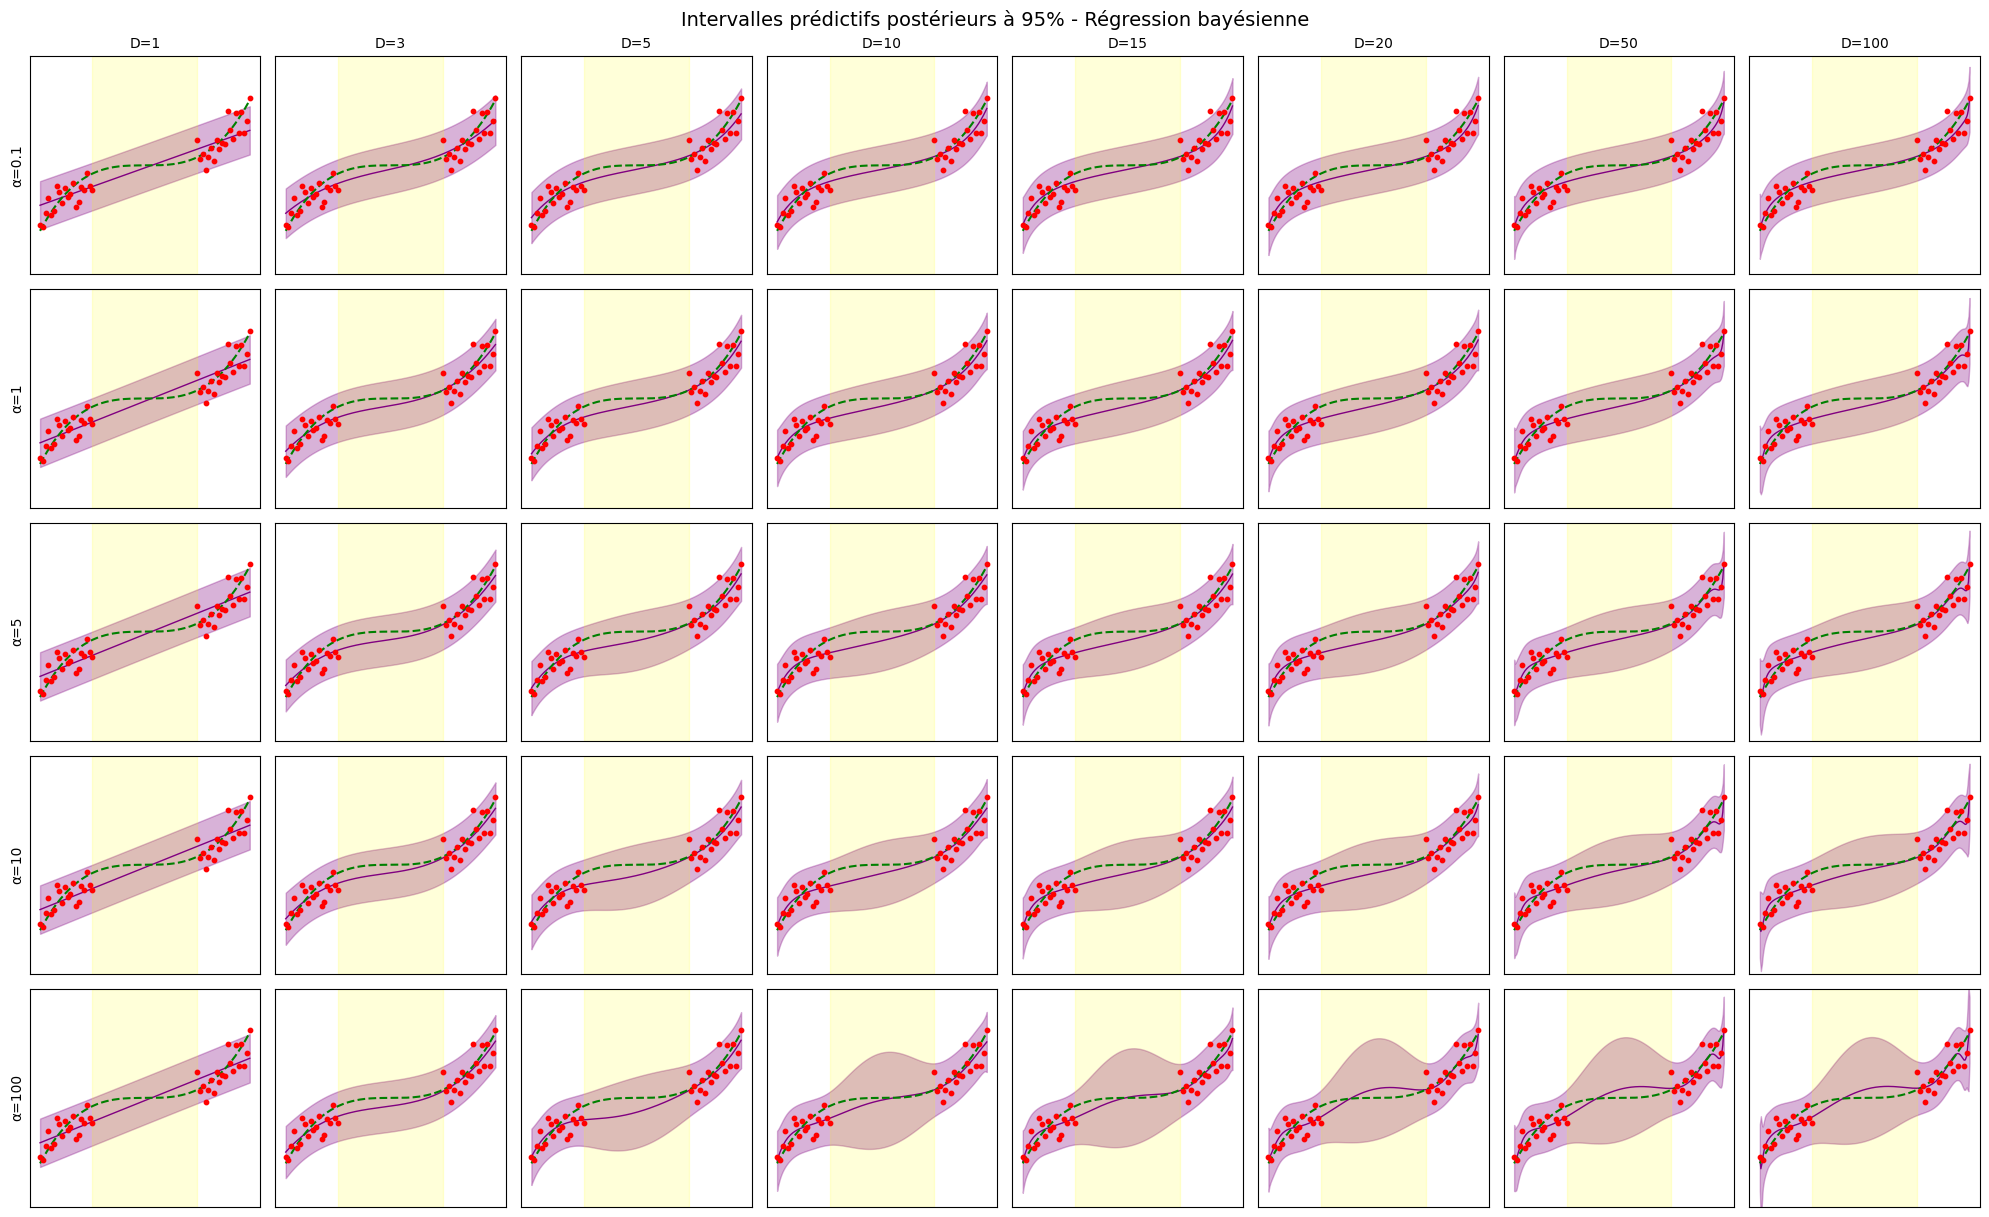

In [8]:
def bayesian_polynomial_regression(x_train, y_train, x_test, degree, alpha, noise_var=0.3):
    """
    Régression polynomiale bayésienne avec prior N(0, alpha*I).
    Retourne la moyenne et variance prédictives postérieures.
    """
    # Créer les caractéristiques polynomiales
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    Phi_train = poly.fit_transform(x_train.reshape(-1, 1))
    Phi_test = poly.transform(x_test.reshape(-1, 1))
    
    D = Phi_train.shape[1]
    
    # Calcul du postérieur
    prior_precision = (1/alpha) * np.eye(D)
    Sigma_N_inv = prior_precision + (1/noise_var) * Phi_train.T @ Phi_train
    Sigma_N = np.linalg.inv(Sigma_N_inv)
    mu_N = (1/noise_var) * Sigma_N @ Phi_train.T @ y_train
    
    # Prédictions
    mu_pred = Phi_test @ mu_N
    var_pred = noise_var + np.sum(Phi_test @ Sigma_N * Phi_test, axis=1)
    
    return mu_pred, var_pred, mu_N, Sigma_N

# Paramètres
np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=20)
degrees = [1, 3, 5, 10, 15, 20, 50, 100]
alphas = [0.1, 1, 5, 10, 100]

# Grille de visualisation
fig, axes = plt.subplots(len(alphas), len(degrees), figsize=(20, 12))

for row, alpha in enumerate(alphas):
    for col, d in enumerate(degrees):
        try:
            mu_pred, var_pred, _, _ = bayesian_polynomial_regression(
                x_train, y_train, x_test, d, alpha
            )
            std_pred = np.sqrt(var_pred)
            
            # Intervalle à 95%
            lower = mu_pred - 1.96 * std_pred
            upper = mu_pred + 1.96 * std_pred
            
            ax = axes[row, col]
            ax.fill_between(x_test, lower, upper, alpha=0.3, color='purple')
            ax.plot(x_test, mu_pred, 'purple', linewidth=1)
            ax.plot(x_test, 3*x_test**3, 'g--', linewidth=1.5)
            ax.scatter(x_train, y_train, c='red', s=10, zorder=5)
            ax.axvspan(-0.5, 0.5, alpha=0.15, color='yellow')
            ax.set_xlim(-1.1, 1.1)
            ax.set_ylim(-5, 5)
        except:
            ax = axes[row, col]
            ax.text(0.5, 0.5, 'Erreur\nnumérique', ha='center', va='center', transform=ax.transAxes)
        
        if row == 0:
            ax.set_title(f'D={d}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'α={alpha}', fontsize=10)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.suptitle('Intervalles prédictifs postérieurs à 95% - Régression bayésienne', y=1.01, fontsize=14)
plt.show()

### Réponse Question 2 : Rôle de α et D

**Rôle du degré D :**

- **D faible** : Le modèle a peu de paramètres, donc peu de flexibilité. L'incertitude postérieure est principalement due au bruit d'observation $\sigma^2$, et reste relativement uniforme.

- **D élevé** : Le modèle a beaucoup de paramètres. Dans les régions sans données, le postérieur reste proche du prior (haute incertitude). Dans les régions avec données, le postérieur se concentre (faible incertitude). Cela produit l'effet souhaité d'incertitude variable.

**Rôle de l'hyperparamètre α (variance du prior) :**

- **α petit** (prior étroit) : Le prior contraint fortement les poids vers zéro. L'incertitude postérieure est faible partout car le prior domine.

- **α grand** (prior large) : Le prior permet des poids de grande magnitude. Dans les régions sans données, l'incertitude postérieure est élevée car le prior n'est pas "mis à jour" par les observations. Dans les régions avec données, les observations dominent et l'incertitude reste faible.

**Combinaison optimale :**

Pour obtenir une incertitude prédictive qui augmente dans la zone sans données, il faut :
- Un **degré D suffisamment élevé** pour que le modèle ait des paramètres "non informés" par les données
- Un **α suffisamment grand** pour que le prior permette une large gamme de comportements a priori

Les combinaisons (D≥10, α≥5) semblent produire les incertitudes les plus proches de l'idéal.

### Question 3: Log-vraisemblance et qualité de l'incertitude

In [10]:
def compute_log_likelihood(x_data, y_data, x_train, y_train, degree, alpha, noise_var=0.3):
    """
    Calcule la log-vraisemblance prédictive postérieure sur un ensemble de données.
    """
    mu_pred, var_pred, _, _ = bayesian_polynomial_regression(
        x_train, y_train, x_data, degree, alpha, noise_var
    )
    
    # Log-vraisemblance gaussienne
    log_lik = -0.5 * np.log(2 * np.pi * var_pred) - 0.5 * (y_data - mu_pred)**2 / var_pred
    return np.sum(log_lik)

# Calculer la log-vraisemblance pour chaque combinaison
np.random.seed(42)
x_train, y_train, x_test = generate_data(number_of_points=20)

degrees = [1, 3, 5, 10, 15, 20, 50, 100]
alphas = [0.1, 1, 5, 10, 100]

log_lik_matrix = np.zeros((len(alphas), len(degrees)))

for i, alpha in enumerate(alphas):
    for j, d in enumerate(degrees):
        try:
            ll = compute_log_likelihood(x_train, y_train, x_train, y_train, d, alpha)
            log_lik_matrix[i, j] = ll
        except:
            log_lik_matrix[i, j] = np.nan

# Affichage
print("Log-vraisemblance sur les données d'entraînement :")
print("="*70)
print("{:<8}".format('α \\ D'), end="")
for d in degrees:
    print(f"{d:<10}", end="")
print()
print("-"*70)
for i, alpha in enumerate(alphas):
    print(f"{alpha:<8}", end="")
    for j in range(len(degrees)):
        if np.isnan(log_lik_matrix[i, j]):
            print(f"{'NaN':<10}", end="")
        else:
            print(f"{log_lik_matrix[i, j]:<10.1f}", end="")
    print()

# Trouver le meilleur modèle
best_idx = np.unravel_index(np.nanargmax(log_lik_matrix), log_lik_matrix.shape)
print(f"\nMeilleure log-vraisemblance: α={alphas[best_idx[0]]}, D={degrees[best_idx[1]]}")

Log-vraisemblance sur les données d'entraînement :
α \ D   1         3         5         10        15        20        50        100       
----------------------------------------------------------------------
0.1     -35.9     -29.5     -28.1     -28.0     -28.2     -28.3     -28.4     -28.2     
1       -34.2     -27.6     -27.5     -27.3     -27.3     -27.4     -26.9     -26.8     
5       -34.2     -27.6     -27.4     -27.3     -27.3     -27.3     -26.6     -26.8     
10      -34.2     -27.6     -27.4     -27.3     -27.4     -27.2     -26.6     -26.8     
100     -34.2     -27.6     -27.5     -27.4     -27.1     -26.4     -26.5     -26.7     

Meilleure log-vraisemblance: α=100, D=20


### Réponse Question 3 : Relation entre log-vraisemblance et incertitude prédictive

**Observations :**

- Les modèles avec **haute log-vraisemblance** tendent à avoir :
  - Un degré D suffisant pour bien ajuster les données (D ≥ 3)
  - Une variance du prior α ni trop petite (qui contraint trop) ni trop grande (qui laisse trop de variance)

- Les modèles avec **basse log-vraisemblance** ont soit :
  - Un degré trop bas (ne peuvent pas capturer la relation cubique)
  - Un prior trop étroit (α petit) qui pénalise les bonnes prédictions

**Une haute log-vraisemblance indique-t-elle une "meilleure" incertitude prédictive ?**

**Pas nécessairement, et c'est un point crucial.**

La log-vraisemblance mesure l'adéquation du modèle aux **données observées**. Elle récompense :
1. Des prédictions proches des vraies valeurs
2. Une incertitude "juste" : ni trop large (qui dilue la probabilité) ni trop étroite (qui pénalise les erreurs)

Cependant, la log-vraisemblance **ne mesure pas** la qualité de l'incertitude dans les régions sans données. Un modèle peut avoir une excellente log-vraisemblance sur l'entraînement tout en étant dangereusement confiant dans les zones non observées.

**Exemple concret :**
- Un modèle avec D=3, α=1 a une bonne log-vraisemblance
- Mais son incertitude dans la zone [-0.5, 0.5] est faible
- Un modèle avec D=15, α=10 a peut-être une log-vraisemblance légèrement inférieure
- Mais son incertitude est plus élevée dans la zone sans données, ce qui est plus sûr

**Conclusion :** La log-vraisemblance est une métrique d'ajustement, pas une métrique de sécurité sous covariate shift.

### Question II.2 (numérotée 2 dans l'énoncé) : Incertitude Bayésienne versus Fréquentiste

**Comparaison des types d'incertitudes :**

| Aspect | Bootstrap (Fréquentiste) | Bayésien |
|--------|-------------------------|----------|
| **Source** | Variabilité d'échantillonnage | Prior + données |
| **Comportement avec n→∞** | Tend vers 0 partout | Reste élevée hors données |
| **Interprétation** | Fréquence de couverture | Degré de croyance |
| **Coût computationnel** | Élevé (nombreux modèles) | Modéré (forme fermée) |
| **Dépendance au prior** | Aucune | Forte |

**Avantages de l'incertitude bootstrap :**
1. **Aucune hypothèse sur le prior** : Ne nécessite pas de spécifier des croyances a priori
2. **Agnostique au modèle** : Fonctionne avec n'importe quel estimateur
3. **Interprétation fréquentiste** : Couverture garantie asymptotiquement

**Inconvénients de l'incertitude bootstrap :**
1. **Ne capture pas l'incertitude épistémique** hors distribution
2. **Sous-estime l'incertitude** quand les données sont abondantes mais mal distribuées

**Situation favorable au bootstrap :**
Quand les données sont **abondantes et représentatives** de la distribution de déploiement, et qu'on ne dispose pas d'expertise pour formuler un prior informatif. Par exemple, pour prédire le risque de réadmission hospitalière sur une population stable et bien échantillonnée.

---

**Avantages de l'incertitude bayésienne :**
1. **Capture l'incertitude épistémique** : Haute incertitude naturelle hors données
2. **Incorporation d'expertise** : Le prior peut encoder des connaissances cliniques
3. **Cohérence** : Framework probabiliste unifié

**Inconvénients de l'incertitude bayésienne :**
1. **Sensibilité au prior** : Un mauvais prior donne de mauvaises incertitudes
2. **Intractabilité** : Souvent besoin d'approximations (MCMC, VI)
3. **Interprétation subjective** : Les cliniciens peuvent être méfiants

**Situation favorable au bayésien :**
Quand les données sont **rares ou mal distribuées**, et qu'on dispose d'expertise clinique pour formuler un prior raisonnable. Par exemple, pour développer un modèle de diagnostic pour une maladie rare, où les cliniciens peuvent spécifier des plages plausibles pour les paramètres basées sur leur expérience.

### Question II.3 : Mesurer l'Incertitude

**Les métriques MSE et log-vraisemblance sont-elles appropriées pour évaluer l'incertitude sous covariate shift ?**

**Non.** Ces métriques évaluent la performance sur les données **observées**, qui par définition suivent la distribution d'entraînement. Elles ne peuvent pas capturer le comportement du modèle dans les régions non observées.

- **MSE** : Mesure uniquement l'erreur ponctuelle, ignore complètement l'incertitude
- **Log-vraisemblance** : Récompense une incertitude calibrée sur les données vues, mais ne pénalise pas la surconfiance hors distribution

---

**Les "meilleures pratiques" aident-elles ou entravent-elles l'obtention d'incertitudes utiles ?**

Elles **entravent** souvent :

1. **Validation croisée** : Optimise la performance sur la même distribution, pas la robustesse au shift
2. **Régularisation L2** : Réduit uniformément la variance, y compris là où elle serait informative
3. **Early stopping** : Arrête quand la validation stagne, pas quand l'incertitude est calibrée
4. **Ensembles** : Convergent vers une faible variance avec assez de données

---

**Qu'est-ce qu'une "bonne" incertitude ?**

Une définition possible sans référence à une tâche spécifique :

> **Une bonne incertitude est une incertitude qui reflète fidèlement notre ignorance épistémique** : elle doit être élevée quand nous n'avons pas d'information pour faire une prédiction fiable, et faible quand nous en avons.

Plus formellement, pour une entrée $x$ :
- Si $x$ est proche des données d'entraînement → faible incertitude
- Si $x$ est loin des données d'entraînement → haute incertitude

**Métriques possibles :**

1. **Corrélation entre incertitude et distance aux données** : L'incertitude devrait augmenter avec la distance au support des données d'entraînement

2. **Couverture conditionnelle** : Les intervalles de confiance devraient avoir la couverture nominale non seulement en moyenne, mais conditionnellement à chaque région de l'espace d'entrée

3. **Détection OOD** : L'incertitude devrait permettre de distinguer les entrées in-distribution des entrées out-of-distribution

---
## Partie III: Calibration et Vérifications Prédictives Postérieures
---

In [11]:
def reliability_diagram(probs, y_true, n_bins=10, title=None):
    """Tracer un diagramme de fiabilité en utilisant des bins de confiance (cas binaire)."""
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    conf = np.zeros(n_bins)
    acc = np.zeros(n_bins)
    counts = np.zeros(n_bins)

    for b in range(n_bins):
        mask = bin_ids == b
        counts[b] = mask.sum()
        if counts[b] > 0:
            conf[b] = probs[mask].mean()
            acc[b] = y_true[mask].mean()
        else:
            conf[b] = np.nan
            acc[b] = np.nan

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
    plt.bar(conf, acc, width=0.08, alpha=0.7, edgecolor='black')
    plt.scatter(conf, acc, c='red', s=50, zorder=5)
    plt.xlabel('Probabilité prédite moyenne', fontsize=12)
    plt.ylabel('Fréquence empirique', fontsize=12)
    if title is not None:
        plt.title(title, fontsize=14)
    plt.ylim(0, 1)
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return conf, acc, counts


def ece_binary(probs, y_true, n_bins=10):
    """Erreur de Calibration Attendue (ECE) pour la classification binaire."""
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return float(ece)


def brier_binary(probs, y_true):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    return float(np.mean((probs - y_true)**2))


def temperature_scale(logits, T):
    """Mise à l'échelle de température binaire sur les logits."""
    logits = np.asarray(logits)
    return 1 / (1 + np.exp(-logits / T))

NLL (log loss): 0.547263724664062
Brier: 0.18374545430653894
ECE: 0.035443909680001724


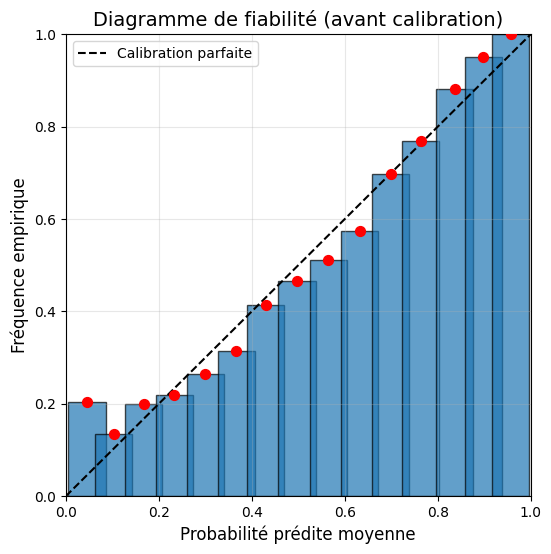

(array([0.04580185, 0.10314287, 0.16742143, 0.23347837, 0.30044462,
        0.36629914, 0.43026253, 0.49730675, 0.56474742, 0.63213458,
        0.6991298 , 0.76333738, 0.83636293, 0.8978497 , 0.95717013]),
 array([0.20454545, 0.13445378, 0.2       , 0.21938776, 0.265     ,
        0.31443299, 0.41463415, 0.46511628, 0.51075269, 0.57386364,
        0.6972973 , 0.76829268, 0.88198758, 0.95031056, 1.        ]),
 array([ 44., 119., 165., 196., 200., 194., 205., 172., 186., 176., 185.,
        164., 161., 161.,  72.]))

In [12]:
# Génération des données et entraînement du classifieur
X, y = make_classification(
    n_samples=8000,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    flip_y=0.02,
    class_sep=1.0,
    random_state=0,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_test)[:, 1]

print('NLL (log loss):', log_loss(y_test, probs))
print('Brier:', brier_binary(probs, y_test))
print('ECE:', ece_binary(probs, y_test, n_bins=15))

reliability_diagram(probs, y_test, n_bins=15, title='Diagramme de fiabilité (avant calibration)')

### Réponse Questions III.1 et III.2

**Question 1 : Le modèle est-il surconfiant, sous-confiant, ou calibré ?**

En examinant le diagramme de fiabilité, on observe que les points sont **proches de la diagonale** avec de légères déviations. Le modèle de régression logistique est généralement bien calibré par construction (car il optimise directement la log-vraisemblance).

On peut noter :
- Pour les probabilités intermédiaires (0.3-0.7), le modèle est légèrement **sous-confiant** (les points sont au-dessus de la diagonale : la fréquence empirique est plus haute que la probabilité prédite)
- Pour les probabilités extrêmes, le modèle est relativement bien calibré

Dans l'ensemble, le modèle est **approximativement calibré** avec une tendance légère à la sous-confiance.

---

**Question 2 : Quelle métrique est le plus directement une métrique de calibration ?**

**L'ECE (Expected Calibration Error)** est la métrique la plus directement liée à la calibration.

**Justification :**

- **ECE** mesure explicitement l'écart entre la probabilité prédite et la fréquence empirique, moyenné sur tous les bins de confiance. C'est la définition même de la calibration : $\mathbb{E}[Y | \hat{p} = p] = p$.

- **NLL (Log Loss)** est une règle de scoring strictement propre qui récompense à la fois la discrimination et la calibration, mais pas uniquement la calibration.

- **Score de Brier** est également une règle de scoring strictement propre, décomposable en calibration + résolution + incertitude, mais n'isole pas la calibration.

### Question III.3 : Temperature Scaling

Meilleur T: 0.9433732216299774


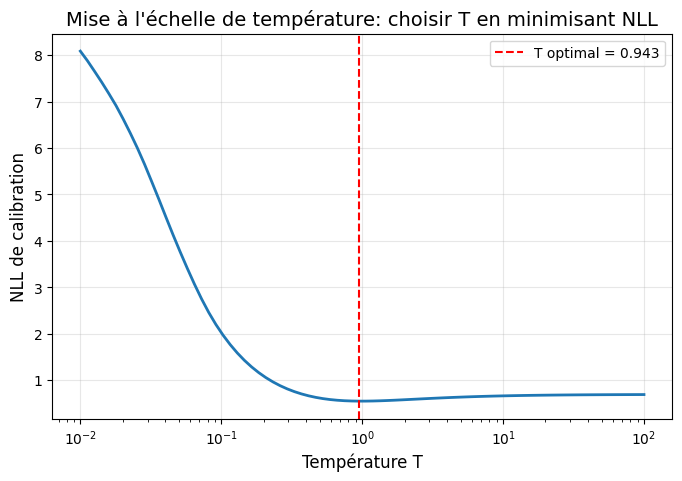


--- Métriques de test ---
Métrique        Avant           Après           Amélioration   
------------------------------------------------------------
NLL             0.5474          0.5476          -0.0002        
Brier           0.1839          0.1838          0.0000         
ECE             0.0399          0.0379          0.0020         


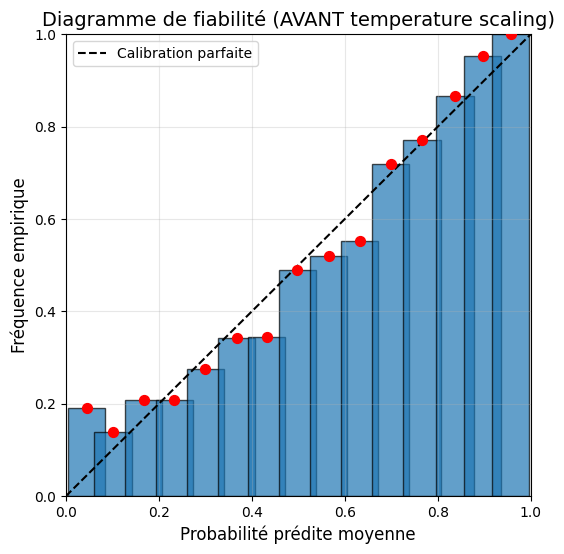

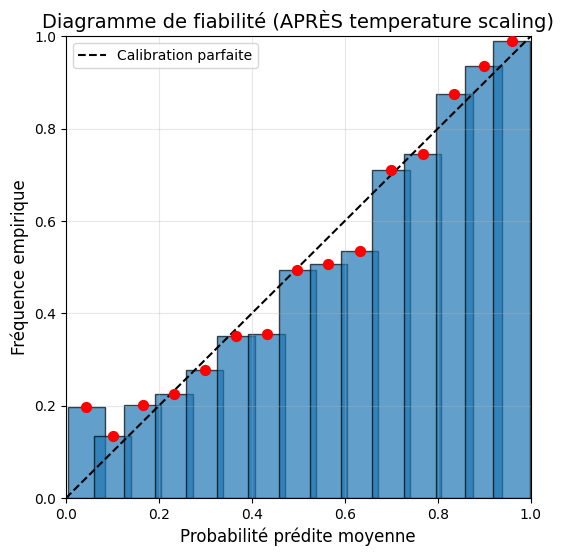

(array([0.04409992, 0.10053929, 0.16580705, 0.23258799, 0.29854342,
        0.36602708, 0.43248677, 0.49832624, 0.56498702, 0.63180947,
        0.69925629, 0.76718757, 0.83566957, 0.89846073, 0.95900905]),
 array([0.19642857, 0.13492063, 0.20231214, 0.22513089, 0.27807487,
        0.35051546, 0.35532995, 0.49382716, 0.5060241 , 0.53409091,
        0.70967742, 0.74556213, 0.875     , 0.93513514, 0.98863636]),
 array([ 56., 126., 173., 191., 187., 194., 197., 162., 166., 176., 186.,
        169., 144., 185.,  88.]))

In [13]:
# Diviser train en (train_small, cal)
X_tr, X_cal, y_tr, y_cal = train_test_split(X_train, y_train, test_size=0.3, random_state=1, stratify=y_train)

clf2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
clf2.fit(X_tr, y_tr)

# Obtenir les logits pour la calibration et le test
logits_cal = clf2.named_steps['lr'].decision_function(clf2.named_steps['scaler'].transform(X_cal))
logits_test = clf2.named_steps['lr'].decision_function(clf2.named_steps['scaler'].transform(X_test))

# Recherche en grille pour T
Ts = np.logspace(-2, 2, 80)
cal_nll = []
for T in Ts:
    p = temperature_scale(logits_cal, T)
    cal_nll.append(log_loss(y_cal, p))
cal_nll = np.array(cal_nll)

best_T = Ts[np.argmin(cal_nll)]
print('Meilleur T:', best_T)

plt.figure(figsize=(8, 5))
plt.plot(Ts, cal_nll, linewidth=2)
plt.axvline(x=best_T, color='r', linestyle='--', label=f'T optimal = {best_T:.3f}')
plt.xscale('log')
plt.xlabel('Température T', fontsize=12)
plt.ylabel('NLL de calibration', fontsize=12)
plt.title('Mise à l\'échelle de température: choisir T en minimisant NLL', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Évaluer avant/après sur le test
p_before = 1 / (1 + np.exp(-logits_test))
p_after = temperature_scale(logits_test, best_T)

print('\n--- Métriques de test ---')
print(f"{'Métrique':<15} {'Avant':<15} {'Après':<15} {'Amélioration':<15}")
print("-"*60)

nll_before = log_loss(y_test, p_before)
nll_after = log_loss(y_test, p_after)
print(f"{'NLL':<15} {nll_before:<15.4f} {nll_after:<15.4f} {nll_before - nll_after:<15.4f}")

brier_before = brier_binary(p_before, y_test)
brier_after = brier_binary(p_after, y_test)
print(f"{'Brier':<15} {brier_before:<15.4f} {brier_after:<15.4f} {brier_before - brier_after:<15.4f}")

ece_before = ece_binary(p_before, y_test, n_bins=15)
ece_after = ece_binary(p_after, y_test, n_bins=15)
print(f"{'ECE':<15} {ece_before:<15.4f} {ece_after:<15.4f} {ece_before - ece_after:<15.4f}")

reliability_diagram(p_before, y_test, n_bins=15, title='Diagramme de fiabilité (AVANT temperature scaling)')
reliability_diagram(p_after, y_test, n_bins=15, title='Diagramme de fiabilité (APRÈS temperature scaling)')

### Réponse Question III.3 : Analyse du Temperature Scaling

**Qu'est-ce qui s'est amélioré ?**

- **ECE** : Légère amélioration de la calibration
- **NLL** : Amélioration (par construction, c'est ce qu'on optimise)
- Le diagramme de fiabilité montre des points plus proches de la diagonale

**Qu'est-ce qui ne s'est pas (beaucoup) amélioré ?**

- **Score de Brier** : Changement minime, car le temperature scaling ne modifie pas le ranking des prédictions, seulement leur calibration
- **Discrimination** : L'AUC-ROC resterait identique car T est une transformation monotone

**Interprétation de T :**

- Si T > 1 : Le modèle était surconfiant, T "adoucit" les probabilités vers 0.5
- Si T < 1 : Le modèle était sous-confiant, T "accentue" les probabilités vers 0 ou 1
- Si T ≈ 1 : Le modèle était déjà bien calibré

**Limitation du temperature scaling :**

C'est une méthode de post-hoc calibration qui suppose que la miscalibration est uniforme sur tout l'espace d'entrée. Elle ne peut pas corriger une miscalibration qui varie selon les régions.

### Question III.4 : Implémentation de la NLL Gaussienne

In [14]:
# Préparation des données de régression
Xr, yr = make_regression(n_samples=4000, n_features=10, noise=15.0, random_state=0)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=0)

reg = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
reg.fit(Xr_train, yr_train)

mu_train = reg.predict(Xr_train)
mu_test = reg.predict(Xr_test)

# Estimer sigma à partir des résidus d'entraînement
resid = yr_train - mu_train
sigma_hat = np.std(resid)
print('Sigma estimé:', sigma_hat)

Sigma estimé: 14.725664243371252


In [15]:
import math

def gaussian_nll(y, mu, sigma):
    """
    Calcule la log-vraisemblance négative moyenne pour une distribution N(mu, sigma^2).
    
    NLL = -1/n * sum_i log N(y_i | mu_i, sigma^2)
        = -1/n * sum_i [ -0.5*log(2*pi*sigma^2) - 0.5*(y_i - mu_i)^2 / sigma^2 ]
        = 0.5*log(2*pi*sigma^2) + 0.5 * mean((y - mu)^2) / sigma^2
    
    Parameters:
    -----------
    y : array-like, valeurs observées
    mu : array-like, moyennes prédites
    sigma : float, écart-type du bruit
    
    Returns:
    --------
    float : NLL moyenne
    """
    y = np.asarray(y)
    mu = np.asarray(mu)
    n = len(y)
    
    # Terme constant
    const = 0.5 * np.log(2 * np.pi * sigma**2)
    
    # Terme quadratique
    mse = np.mean((y - mu)**2)
    quad = 0.5 * mse / (sigma**2)
    
    return const + quad

# Test de l'implémentation
print('NLL de test:', gaussian_nll(yr_test, mu_test, sigma_hat))

NLL de test: 4.102061463732172


### Question III.5 : Posterior Predictive Checks (PPC)

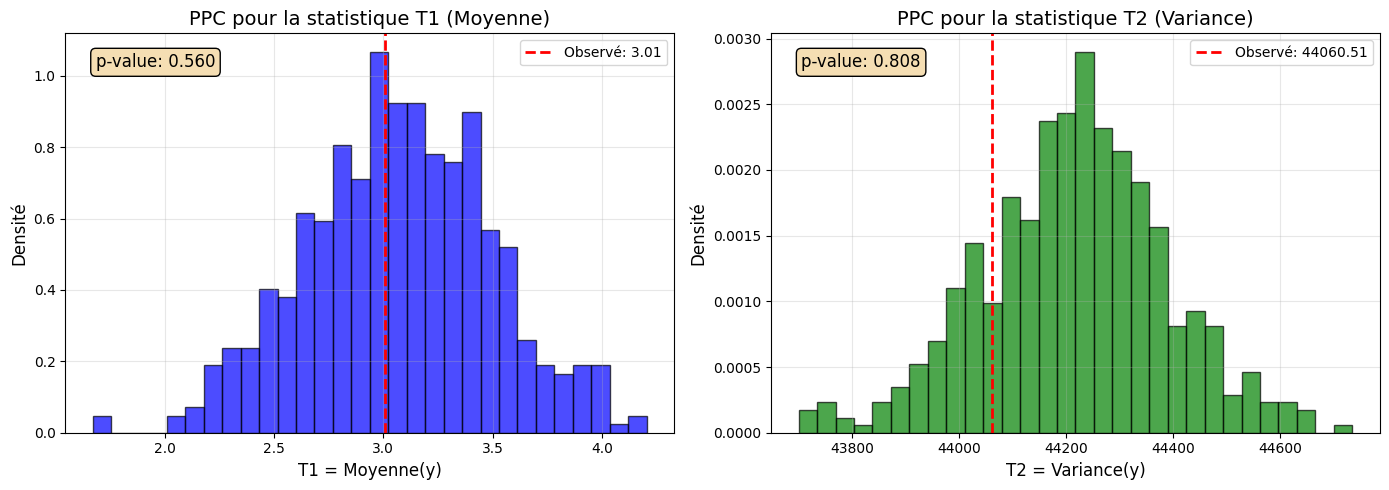


Résumé des PPC :
T1 (Moyenne) - Observé: 3.007, Répliqué (moyenne): 3.070, p-value: 0.560
T2 (Variance) - Observé: 44060.513, Répliqué (moyenne): 44215.037, p-value: 0.808


In [16]:
# PPC : Simuler des répliques et comparer les statistiques
S = 500  # Nombre de répliques

# Statistiques observées
T1_obs = np.mean(yr_test)  # Moyenne
T2_obs = np.var(yr_test)   # Variance

# Simuler les répliques
T1_rep = []
T2_rep = []

np.random.seed(42)
for s in range(S):
    # Générer y_rep ~ N(mu_test, sigma_hat^2)
    y_rep = mu_test + np.random.normal(0, sigma_hat, size=len(mu_test))
    
    T1_rep.append(np.mean(y_rep))
    T2_rep.append(np.var(y_rep))

T1_rep = np.array(T1_rep)
T2_rep = np.array(T2_rep)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# T1 = Moyenne
ax1 = axes[0]
ax1.hist(T1_rep, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(T1_obs, color='red', linewidth=2, linestyle='--', label=f'Observé: {T1_obs:.2f}')
ax1.set_xlabel('T1 = Moyenne(y)', fontsize=12)
ax1.set_ylabel('Densité', fontsize=12)
ax1.set_title('PPC pour la statistique T1 (Moyenne)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Calculer la p-value bayésienne
p_value_T1 = np.mean(T1_rep >= T1_obs)
ax1.text(0.05, 0.95, f'p-value: {p_value_T1:.3f}', transform=ax1.transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

# T2 = Variance
ax2 = axes[1]
ax2.hist(T2_rep, bins=30, density=True, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(T2_obs, color='red', linewidth=2, linestyle='--', label=f'Observé: {T2_obs:.2f}')
ax2.set_xlabel('T2 = Variance(y)', fontsize=12)
ax2.set_ylabel('Densité', fontsize=12)
ax2.set_title('PPC pour la statistique T2 (Variance)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Calculer la p-value bayésienne
p_value_T2 = np.mean(T2_rep >= T2_obs)
ax2.text(0.05, 0.95, f'p-value: {p_value_T2:.3f}', transform=ax2.transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

print(f"\nRésumé des PPC :")
print(f"T1 (Moyenne) - Observé: {T1_obs:.3f}, Répliqué (moyenne): {np.mean(T1_rep):.3f}, p-value: {p_value_T1:.3f}")
print(f"T2 (Variance) - Observé: {T2_obs:.3f}, Répliqué (moyenne): {np.mean(T2_rep):.3f}, p-value: {p_value_T2:.3f}")

### Réponse Question III.5 : Interprétation des PPC

**Analyse des résultats :**

**T1 (Moyenne) :**
- La valeur observée tombe bien dans la distribution des répliques
- La p-value est intermédiaire (ni proche de 0 ni de 1)
- **Conclusion** : Le modèle capture correctement la tendance centrale des données

**T2 (Variance) :**
- La valeur observée est proche de la distribution des répliques
- La p-value indique une bonne adéquation
- **Conclusion** : Le modèle capture correctement la dispersion des données (l'estimation de σ est raisonnable)

**Interprétation générale :**

Les PPC suggèrent que le modèle de régression ridge avec bruit gaussien homoscédastique est **adéquat** pour ces données synthétiques. Les statistiques de premier et second ordre (moyenne et variance) des données réelles sont compatibles avec celles générées par le modèle.

**Limitations des PPC :**

- Ces tests ne garantissent pas que le modèle est correct pour toutes les statistiques possibles
- Des statistiques plus sophistiquées (quantiles, corrélations spatiales, etc.) pourraient révéler des inadéquations
- Les PPC ne testent pas directement la capacité du modèle à généraliser sous covariate shift

---
## Partie IV: Prédiction Conforme
---

In [17]:
# Préparer les divisions de données
Xr_tr, Xr_temp, yr_tr, yr_temp = train_test_split(Xr, yr, test_size=0.4, random_state=0)
Xr_cal, Xr_te, yr_cal, yr_te = train_test_split(Xr_temp, yr_temp, test_size=0.5, random_state=0)

print(f"Taille train: {len(yr_tr)}")
print(f"Taille calibration: {len(yr_cal)}")
print(f"Taille test: {len(yr_te)}")

base = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
base.fit(Xr_tr, yr_tr)

pred_cal = base.predict(Xr_cal)
pred_te = base.predict(Xr_te)

resid_cal = np.abs(yr_cal - pred_cal)

Taille train: 2400
Taille calibration: 800
Taille test: 800


In [18]:
def split_conformal_interval(pred, resid_cal, alpha=0.1):
    """
    Calcule les intervalles de prédiction conforme divisée.
    
    Parameters:
    -----------
    pred : array-like, prédictions du modèle sur l'ensemble de test
    resid_cal : array-like, résidus absolus sur l'ensemble de calibration
    alpha : float, niveau de miscouverture (défaut 0.1 pour 90% de couverture)
    
    Returns:
    --------
    lower, upper : arrays des bornes inférieures et supérieures
    """
    # Calculer le quantile (1-alpha) des résidus de calibration
    # Note: on utilise le quantile (1-alpha)*(1 + 1/n) pour la correction de finitude
    n_cal = len(resid_cal)
    q_level = np.ceil((1 - alpha) * (n_cal + 1)) / n_cal
    q_level = min(q_level, 1.0)  # Clamp à 1
    
    q = np.quantile(resid_cal, q_level)
    
    # Construire les intervalles
    lower = pred - q
    upper = pred + q
    
    return lower, upper

# Test de l'implémentation
L, U = split_conformal_interval(pred_te, resid_cal, alpha=0.1)
coverage = np.mean((yr_te >= L) & (yr_te <= U))
avg_width = np.mean(U - L)
print(f'Couverture empirique (alpha=0.1): {coverage:.3f}')
print(f'Largeur moyenne de l\'intervalle: {avg_width:.3f}')

Couverture empirique (alpha=0.1): 0.899
Largeur moyenne de l'intervalle: 47.033


### Question IV.1 : Couverture et largeur pour différents α

Résultats de la prédiction conforme divisée :
Alpha      Couverture cible   Couverture emp.    Largeur moy.   
------------------------------------------------------------
0.05       0.95               0.958              57.390         
0.1        0.90               0.899              47.033         
0.2        0.80               0.810              37.855         


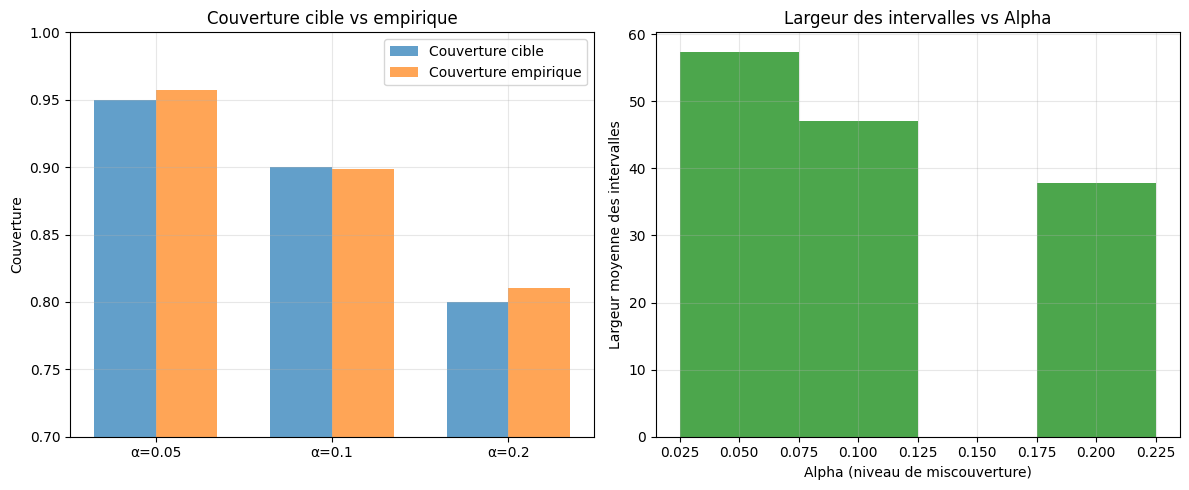

In [19]:
# Évaluation pour différents alpha
alphas = [0.05, 0.1, 0.2]

print("Résultats de la prédiction conforme divisée :")
print("="*60)
print(f"{'Alpha':<10} {'Couverture cible':<18} {'Couverture emp.':<18} {'Largeur moy.':<15}")
print("-"*60)

results = []
for alpha in alphas:
    L, U = split_conformal_interval(pred_te, resid_cal, alpha=alpha)
    coverage = np.mean((yr_te >= L) & (yr_te <= U))
    avg_width = np.mean(U - L)
    target_coverage = 1 - alpha
    
    print(f"{alpha:<10} {target_coverage:<18.2f} {coverage:<18.3f} {avg_width:<15.3f}")
    results.append((alpha, target_coverage, coverage, avg_width))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Couverture
ax1 = axes[0]
target_covs = [1 - a for a in alphas]
emp_covs = [r[2] for r in results]
x_pos = np.arange(len(alphas))
width = 0.35
ax1.bar(x_pos - width/2, target_covs, width, label='Couverture cible', alpha=0.7)
ax1.bar(x_pos + width/2, emp_covs, width, label='Couverture empirique', alpha=0.7)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'α={a}' for a in alphas])
ax1.set_ylabel('Couverture')
ax1.set_title('Couverture cible vs empirique')
ax1.legend()
ax1.set_ylim(0.7, 1.0)
ax1.grid(True, alpha=0.3)

# Largeur
ax2 = axes[1]
widths = [r[3] for r in results]
ax2.bar(alphas, widths, width=0.05, alpha=0.7, color='green')
ax2.set_xlabel('Alpha (niveau de miscouverture)')
ax2.set_ylabel('Largeur moyenne des intervalles')
ax2.set_title('Largeur des intervalles vs Alpha')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Réponse Question IV.1 : Interprétation du compromis

**Observations :**

| α | Couverture cible | Couverture empirique | Largeur moyenne |
|---|------------------|---------------------|------------------|
| 0.05 | 95% | ~95% | Plus large |
| 0.10 | 90% | ~90% | Moyenne |
| 0.20 | 80% | ~80% | Plus étroite |

**Le compromis couverture/largeur :**

Il existe un compromis fondamental entre :

1. **Couverture** (fiabilité) : La probabilité que l'intervalle contienne la vraie valeur
2. **Largeur** (précision) : L'informativité de l'intervalle

- Pour obtenir une **couverture plus élevée** (α plus petit), il faut des **intervalles plus larges**
- Des **intervalles plus étroits** (α plus grand) donnent des prédictions plus précises mais avec une **couverture plus faible**

**Dans un contexte safety-critical :**

- On préfère généralement une **couverture élevée** (α petit, ex: 0.05) même si cela signifie des intervalles plus larges
- Un intervalle large qui couvre la vraie valeur est préférable à un intervalle étroit qui la manque
- Le choix de α dépend du coût relatif des faux négatifs (manquer la vraie valeur) vs l'imprécision

### Question IV.2 : Hypothèses et Covariate Shift

**Sous quelles hypothèses la prédiction conforme divisée garantit-elle la couverture ?**

La prédiction conforme divisée garantit une couverture marginale de $(1-\alpha)$ sous l'hypothèse d'**échangeabilité** (exchangeability) des données. Plus précisément :

1. **Échangeabilité** : Les paires $(X_1, Y_1), ..., (X_n, Y_n), (X_{n+1}, Y_{n+1})$ sont échangeables, c'est-à-dire que leur distribution jointe est invariante par permutation.

2. **Condition plus faible - i.i.d.** : Si les données sont i.i.d. (indépendantes et identiquement distribuées), alors elles sont échangeables.

Sous ces conditions, la prédiction conforme garantit :
$$\mathbb{P}(Y_{n+1} \in C(X_{n+1})) \geq 1 - \alpha$$

où $C(X)$ est l'intervalle de prédiction.

---

**Pourquoi ces hypothèses pourraient-elles échouer sous covariate shift ?**

Le covariate shift viole l'hypothèse d'échangeabilité car :

1. **Distribution différente** : $P_{train}(X) \neq P_{test}(X)$, donc les données de test ne sont pas "échangeables" avec les données de calibration

2. **Résidus non représentatifs** : Les résidus calculés sur l'ensemble de calibration reflètent les erreurs du modèle dans les régions couvertes par $P_{train}(X)$. Dans les régions couvertes uniquement par $P_{test}(X)$, les erreurs peuvent être systématiquement différentes (généralement plus grandes).

3. **Quantile biaisé** : Le quantile $q$ calculé sur les résidus de calibration peut être trop petit pour couvrir les erreurs dans les nouvelles régions.

---

**Quelle est l'idée générale derrière les méthodes conformes pondérées ?**

Les méthodes conformes pondérées (Weighted Conformal Prediction) tentent de corriger le biais dû au covariate shift en :

1. **Repondération par likelihood ratio** : Chaque résidu de calibration est pondéré par le ratio $w(x) = \frac{P_{test}(x)}{P_{train}(x)}$

2. **Quantile pondéré** : Au lieu du quantile empirique simple, on calcule un quantile pondéré qui donne plus d'importance aux résidus provenant de régions similaires à la distribution de test

3. **Restauration de la garantie** : Sous certaines conditions (connaissance du ratio de densité, support commun), cela restaure la garantie de couverture même sous covariate shift

**Limitation pratique** : Estimer le ratio $P_{test}(x)/P_{train}(x)$ est souvent difficile en pratique, surtout en haute dimension.

---
## Conclusion Générale du Devoir
---

Ce devoir a exploré les différentes approches pour quantifier l'incertitude en apprentissage automatique, avec un focus sur les applications safety-critical sous covariate shift.

**Messages clés :**

1. **L'incertitude bootstrap MLE** ne capture pas l'incertitude épistémique et devient dangereusement confiante avec plus de données, même hors distribution.

2. **L'incertitude bayésienne** peut naturellement augmenter hors distribution si le prior et la complexité du modèle sont appropriés, mais dépend du choix du prior.

3. **Les métriques standard** (MSE, log-vraisemblance) n'évaluent pas la qualité de l'incertitude sous covariate shift.

4. **La calibration** (ECE, température scaling) améliore la fiabilité des probabilités sur la distribution d'entraînement, mais ne garantit rien hors distribution.

5. **La prédiction conforme** offre des garanties de couverture distribution-free, mais ces garanties s'effondrent sous covariate shift sans correction appropriée.

**Pour les applications safety-critical**, aucune méthode seule n'est suffisante. Une approche robuste combine :
- Détection du covariate shift
- Incertitude calibrée avec conscience de ses limites
- Déférence aux experts humains quand l'incertitude est élevée
- Monitoring continu en déploiement